Original Class Distribution:
ALERT
0    5138973
2    5138973
1        571
Name: count, dtype: int64

Class Distribution After Under-Sampling:
ALERT
0    571
1    571
2    571
Name: count, dtype: int64
Number of samples before training: 1199
Total time: 0.0041866302490234375 seconds
Training time: 0.0032448768615722656 seconds
Prediction time: 0.0008666515350341797 seconds

 DT ({'All Features'}) Metrics:
Accuracy: 0.9980544747081712
Precision: 0.9980657859017282
Recall: 0.9980544747081712
F1 Score: 0.9980544747081712


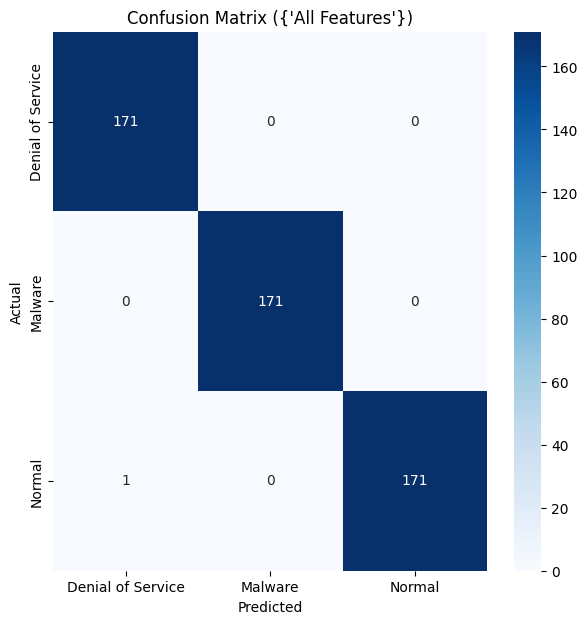

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import time
import numpy as np
import sys
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sys.path.append('/home/ibibers/XAI_Evalation_For_IDS_datasets/Datasets_prepration')
from Simargl import data_preprocessing, evaluate_model, plot_confusion_matrix

le, X, y, X_train, X_test, y_train, y_test, df  = data_preprocessing()
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

import time
start_total_time = time.time()
dt_model = DecisionTreeClassifier()

start_train_time = time.time()
dt_model.fit(X_train, y_train)
end_train_time = time.time()
start_pred_time = time.time()
y_pred_encoded_class = dt_model.predict(X_test)
end_pred_time = time.time()
end_total_time = time.time()

total_time = end_total_time - start_total_time
training_time = end_train_time - start_train_time
prediction_time = end_pred_time - start_pred_time

print("Number of samples before training:", len(X_train))
print(f"Total time: {total_time} seconds")
print(f"Training time: {training_time} seconds")
print(f"Prediction time: {prediction_time} seconds")

y_pred_class = le.inverse_transform(y_pred_encoded_class)
y_test_labels = le.inverse_transform(y_test)

metrics = evaluate_model(y_test_labels, y_pred_class, f" DT ({{'All Features'}})")

plot_confusion_matrix(y_test_labels, y_pred_class, le.classes_, f"Confusion Matrix ({{'All Features'}})")

sys.path.append('/home/ibibers/XAI_Evalation_For_IDS_datasets/XAI_Methods')
from SHAP import explain_with_shap
from LIME import explain_with_lime


shap_values, Shap_explainer = explain_with_shap(dt_model, X_train, X_test, model_type=None, num_samples=5000)



lime_explianer, Lime_exp_Inst = explain_with_lime(
    model=dt_model,
    X_train=X_train,
    X_test=X_test,
    mode='classification',
    num_features=77,
    num_samples=5000,      
    kernel_width=None,      
    random_state=42,       
    discretize_continuous=True,
    return_instance_exp=True
)




In [ ]:
print("SHAP values shape:", shap_values.shape)
print ("SHAP explainer:", Shap_explainer)


SHAP values shape: (514, 27, 3)
SHAP explainer: <shap.explainers._tree.TreeExplainer object at 0x740a315739d0>


In [ ]:
print("LIME explainer:", lime_explianer)
print("LIME explanation instance:", Lime_exp_Inst)
print("LIME explanation instance details:", Lime_exp_Inst.as_list())


LIME explainer: <lime.lime_tabular.LimeTabularExplainer object at 0x740a3244f970>
LIME explanation instance: <lime.explanation.Explanation object at 0x7409aaacbd90>
LIME explanation instance details: [('FLOW_ID <= -1.41', 0.8889784229829529), ('FLOW_DURATION_MILLISECONDS <= -0.28', -0.020145284461731146), ('TCP_WIN_MIN_OUT <= -0.35', 0.019645684087464185), ('OUT_BYTES <= -0.05', -0.017138577797203243), ('TCP_WIN_MIN_IN <= -0.89', -0.015874062062438736), ('TCP_WIN_MAX_OUT <= -0.35', 0.014231401040721889), ('L4_DST_PORT <= -0.26', -0.013449950466801494), ('DST_TOS <= -0.33', -0.012848810335467425), ('SRC_TOS > -0.32', -0.012714283583691682), ('ANOMALY <= -1.27', -0.009099433683929561), ('IN_PKTS <= -0.18', -0.008851960657626248), ('-0.76 < IPV4_SRC_ADDR <= 1.18', -0.006815169524518613), ('-0.84 < IPV4_DST_ADDR <= 0.59', 0.004939721909210746), ('-0.12 < IN_BYTES <= -0.09', -0.004727999474912915), ('TOTAL_FLOWS_EXP <= -1.41', 0.0044394456506926154), ('TCP_WIN_SCALE_IN <= -0.87', -0.0038424

Number of valid SHAP results (all classes): 513
First SHAP result: {'mean_absolute_deviation': 0.0, 'cosine_similarity': 1.0, 'std_deviation': 0.0}
Number of valid LIME results (all classes): 513
First LIME result: {'mean_absolute_deviation': 0.015568763383585555, 'cosine_similarity': 0.599042646398842, 'std_deviation': 0.004033958212058021}
Aggregated Sensitivity Metrics (mean ± std):
       mean_absolute_deviation           cosine_similarity            \
                          mean       std              mean       std   
method                                                                 
LIME                  0.021809  0.003907          0.467994  0.208116   
SHAP                  0.005578  0.008502          0.758621  0.385780   

       std_deviation            
                mean       std  
method                          
LIME        0.007850  0.002931  
SHAP        0.005551  0.008326  


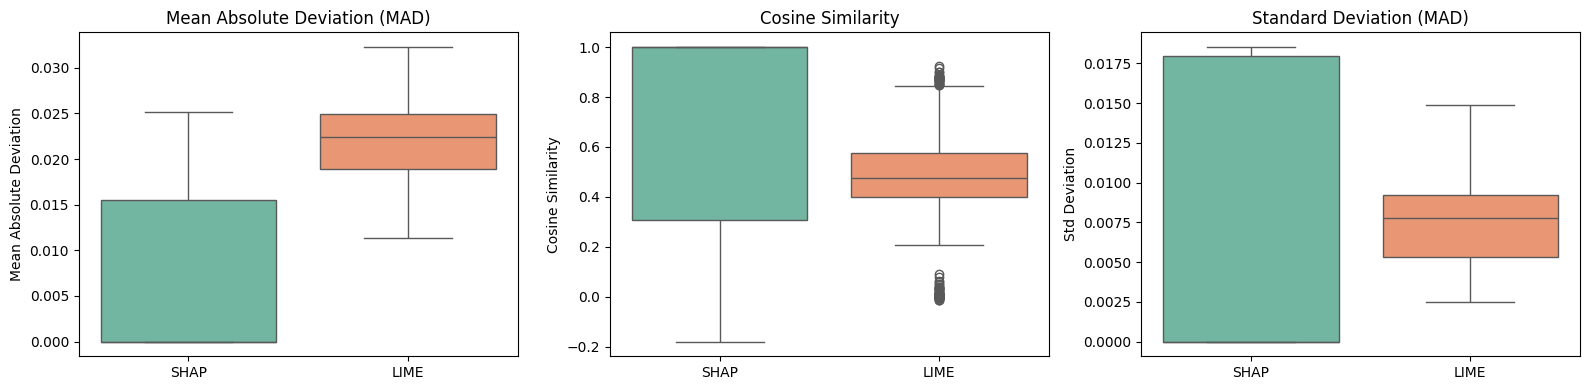

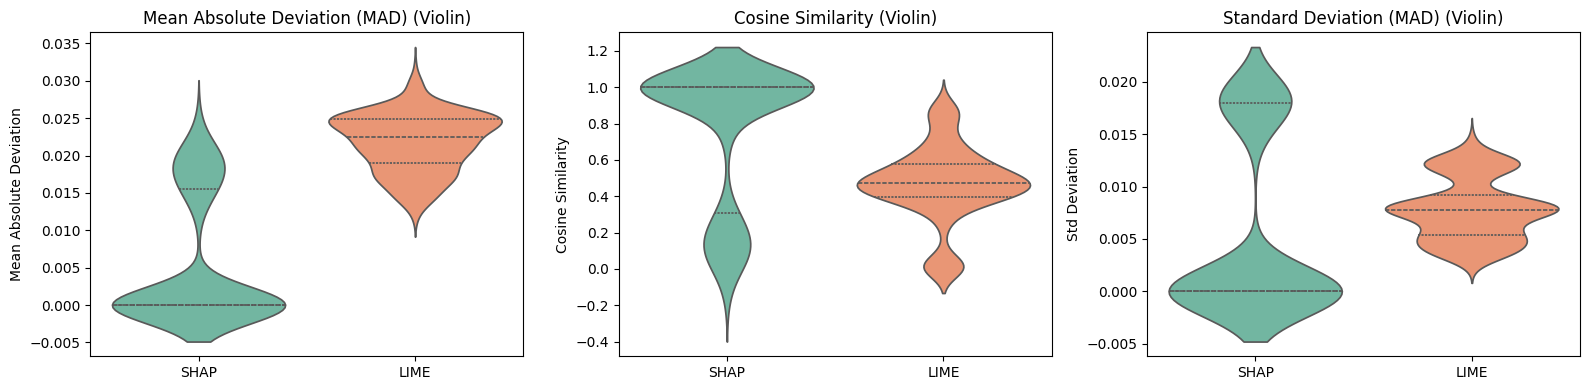


Summary Table (for paper):


,mean_absolute_deviation,cosine_similarity,std_deviation
method,,,
LIME,0.0218 ± 0.0039,0.468 ± 0.2081,0.0079 ± 0.0029
SHAP,0.0056 ± 0.0085,0.7586 ± 0.3858,0.0056 ± 0.0083


In [ ]:
import sys
import importlib

sys.path.append('../XAI_Evalation_For_IDS_datasets/XAI_Evaluation_Metrices')
import Sensitivity
importlib.reload(Sensitivity)
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedShuffleSplit

N_INSTANCES = 1000

def stratified_sample(X, y, n_samples):
    min_class_count = y.value_counts().min()
    if n_samples > min_class_count:
        print(f"Adjusting n_samples from {n_samples} to {min_class_count}")
        n_samples = min_class_count
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=n_samples, random_state=42)
    for _, test_idx in splitter.split(X, y):
        return X.iloc[test_idx], y.iloc[test_idx]

X_sampled, y_sampled = stratified_sample(X_test, y_test, N_INSTANCES)

evaluator = Sensitivity.XAISensitivityEvaluator(model=dt_model, perturbation_std=0.01, num_perturbations=50)

def eval_all_classes_for_instance(idx, instance):
    if not isinstance(instance, pd.DataFrame):
        instance = pd.DataFrame(instance.reshape(1, -1), columns=X_train.columns, index=[idx])
    if not all(instance.columns == X_train.columns):
        instance = instance[X_train.columns]
    shap_results = evaluator.evaluate_all_classes(instance, Shap_explainer, method='shap')
    lime_results = evaluator.evaluate_all_classes(instance, lime_explianer, method='lime')
    return shap_results, lime_results

results = Parallel(n_jobs=-1, backend="loky")(
    delayed(eval_all_classes_for_instance)(idx, X_sampled.iloc[[i]]) for i, idx in enumerate(X_sampled.index)
)

shap_results = [r for res in results if res is not None for r in (res[0] if res[0] is not None else []) if r is not None]
lime_results = [r for res in results if res is not None for r in (res[1] if res[1] is not None else []) if r is not None]

print(f"SHAP results: {len(shap_results)}")
print(f"LIME results: {len(lime_results)}")

import matplotlib.pyplot as plt
import seaborn as sns

shap_df = pd.DataFrame(shap_results)
lime_df = pd.DataFrame(lime_results)

shap_df['method'] = 'SHAP'
lime_df['method'] = 'LIME'

all_df = pd.concat([shap_df, lime_df], ignore_index=True)

agg_metrics = all_df.groupby('method')[['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']].agg(['mean', 'std'])
print(agg_metrics)

plt.figure(figsize=(16, 4))
metrics = ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']
titles = ['MAD', 'Cosine Similarity', 'Std Deviation']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='method', y=metric, data=all_df, palette='Set2')
    plt.title(title)
    plt.xlabel('')
    plt.ylabel(metric.replace('_', ' ').title())
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
for i, (metric, title) in enumerate(zip(metrics, titles)):
    plt.subplot(1, 3, i+1)
    sns.violinplot(x='method', y=metric, data=all_df, palette='Set2', inner='quartile')
    plt.title(title)
    plt.xlabel('')
    plt.ylabel(metric.replace('_', ' ').title())
plt.tight_layout()
plt.show()

summary_table = pd.DataFrame(index=agg_metrics.index)
for col in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    summary_table[col] = agg_metrics[col]['mean'].round(4).astype(str) + " ± " + agg_metrics[col]['std'].round(4).astype(str)
display(summary_table)

In [ ]:
from scipy.stats import mannwhitneyu, shapiro, levene, chi2_contingency
from scipy import stats
import numpy as np

print("Mann-Whitney U Tests")
for metric in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    stat, p_value = mannwhitneyu(shap_df[metric], lime_df[metric], alternative='two-sided')
    sig = '**' if p_value < 0.001 else ''
    print(f"  {metric}: U={stat:.2f}, p={p_value:.2e} {sig}")

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

print("\nEffect Sizes (Cohen's d)")
for metric in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    d = cohens_d(shap_df[metric], lime_df[metric])
    mag = 'negligible' if abs(d) < 0.2 else 'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'
    print(f"  {metric}: d={d:.2f} ({mag})")

print("\n95% CI (LIME - SHAP)")
for metric in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    shap_vals = shap_df[metric].values
    lime_vals = lime_df[metric].values
    diff = np.mean(lime_vals) - np.mean(shap_vals)
    n1, n2 = len(shap_vals), len(lime_vals)
    s1, s2 = np.std(shap_vals, ddof=1), np.std(lime_vals, ddof=1)
    se_diff = np.sqrt(s1**2/n1 + s2**2/n2)
    dof = ((s1**2/n1 + s2**2/n2)**2) / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
    t_crit = stats.t.ppf(0.975, dof)
    ci_lower, ci_upper = diff - t_crit * se_diff, diff + t_crit * se_diff
    print(f"  {metric}: {diff:.6f} [{ci_lower:.6f}, {ci_upper:.6f}]")

print("\nShapiro-Wilk (normality)")
for metric in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    shap_sample = shap_df[metric].sample(min(5000, len(shap_df)), random_state=42)
    lime_sample = lime_df[metric].sample(min(5000, len(lime_df)), random_state=42)
    shap_stat, shap_p = shapiro(shap_sample)
    lime_stat, lime_p = shapiro(lime_sample)
    print(f"  {metric}: SHAP W={shap_stat:.4f} p={shap_p:.2e} | LIME W={lime_stat:.4f} p={lime_p:.2e}")


print("\nLevene's Test (variance equality)")
for metric in ['mean_absolute_deviation', 'cosine_similarity', 'std_deviation']:
    stat, p_value = levene(shap_df[metric], lime_df[metric])
    print(f"  {metric}: F={stat:.2f}, p={p_value:.4e}")


threshold = 0.95
shap_stable = (shap_df['cosine_similarity'] >= threshold).sum()
lime_stable = (lime_df['cosine_similarity'] >= threshold).sum()

print(f"\nStability (cos_sim >= {threshold})")
print(f"  SHAP: {shap_stable}/{len(shap_df)} ({100*shap_stable/len(shap_df):.1f}%)")
print(f"  LIME: {lime_stable}/{len(lime_df)} ({100*lime_stable/len(lime_df):.1f}%)")

contingency = np.array([
    [shap_stable, len(shap_df) - shap_stable],
    [lime_stable, len(lime_df) - lime_stable]
])
chi2, p_chi, dof, _ = chi2_contingency(contingency)
print(f"  Chi-square: χ²={chi2:.2f}, p={p_chi:.4e}")

STATISTICAL VALIDATION OF XAI SENSITIVITY COMPARISON

1. MANN-WHITNEY U TESTS (all metrics)
--------------------------------------------------------------------------------
mean_absolute_deviation:
  U-statistic: 18327.00, p-value: 3.91e-131
  Result: ***Highly significant***

cosine_similarity:
  U-statistic: 198533.00, p-value: 4.95e-47
  Result: ***Highly significant***

std_deviation:
  U-statistic: 81057.00, p-value: 1.59e-27
  Result: ***Highly significant***


2. EFFECT SIZES (Cohen's d)
--------------------------------------------------------------------------------
Interpretation: |d| < 0.2=negligible, 0.2-0.5=small, 0.5-0.8=medium, >0.8=large

mean_absolute_deviation: d = -2.45 (large/very large)
cosine_similarity: d = 0.94 (large/very large)
std_deviation: d = -0.37 (small)


3. 95% CONFIDENCE INTERVALS (difference: LIME - SHAP)
--------------------------------------------------------------------------------
mean_absolute_deviation:
  Mean difference: 0.016230
  95% CI: [0.0

[3/4] Evaluating fairness across features...
  - Processing: L4_DST_PORT


LIME Fairness: 100%|██████████| 514/514 [00:41<00:00, 12.53it/s]


  - Processing: FLOW_DURATION_MILLISECONDS


LIME Fairness: 100%|██████████| 514/514 [00:50<00:00, 10.08it/s]


  - Processing: IN_PKTS


LIME Fairness: 100%|██████████| 514/514 [01:20<00:00,  6.42it/s]


  - Processing: TCP_FLAGS


LIME Fairness: 100%|██████████| 514/514 [01:11<00:00,  7.23it/s]


[4/4] Calculating overall fairness scores...

SAVING RESULTS
✓ Results saved: Simargl2022_DecisionTree_Fairness_Results.csv
✓ Statistical tests saved: Simargl2022_DecisionTree_Fairness_StatisticalTests.csv

GENERATING VISUALIZATIONS
✓ Plot saved: Simargl2022_DecisionTree_MAD_Comparison.png


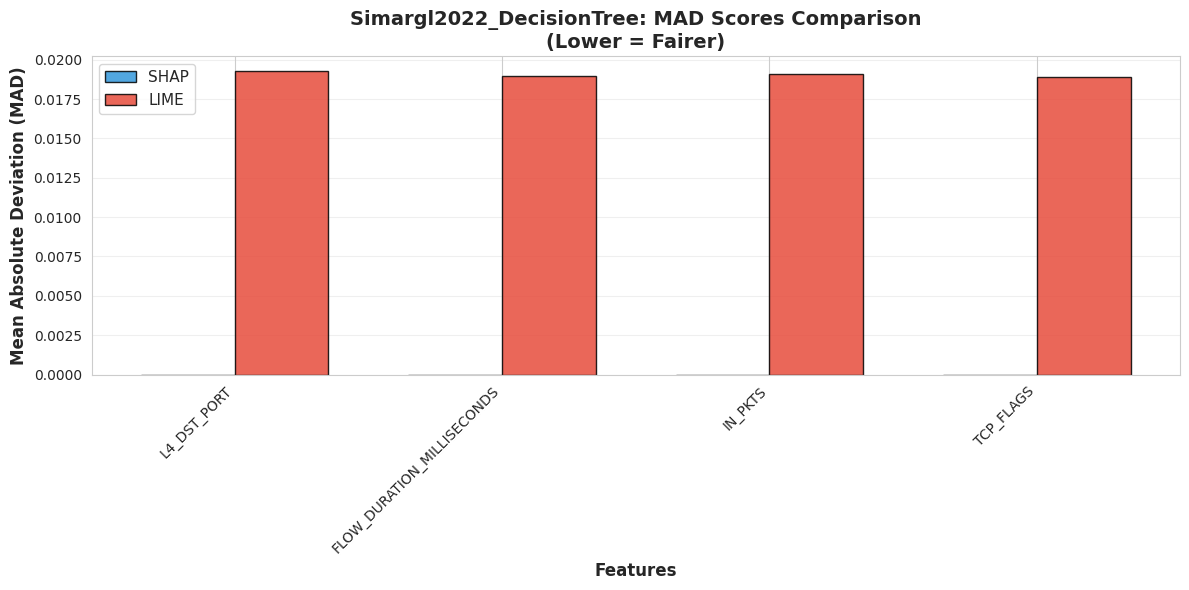

✓ Plot saved: Simargl2022_DecisionTree_Cosine_Comparison.png


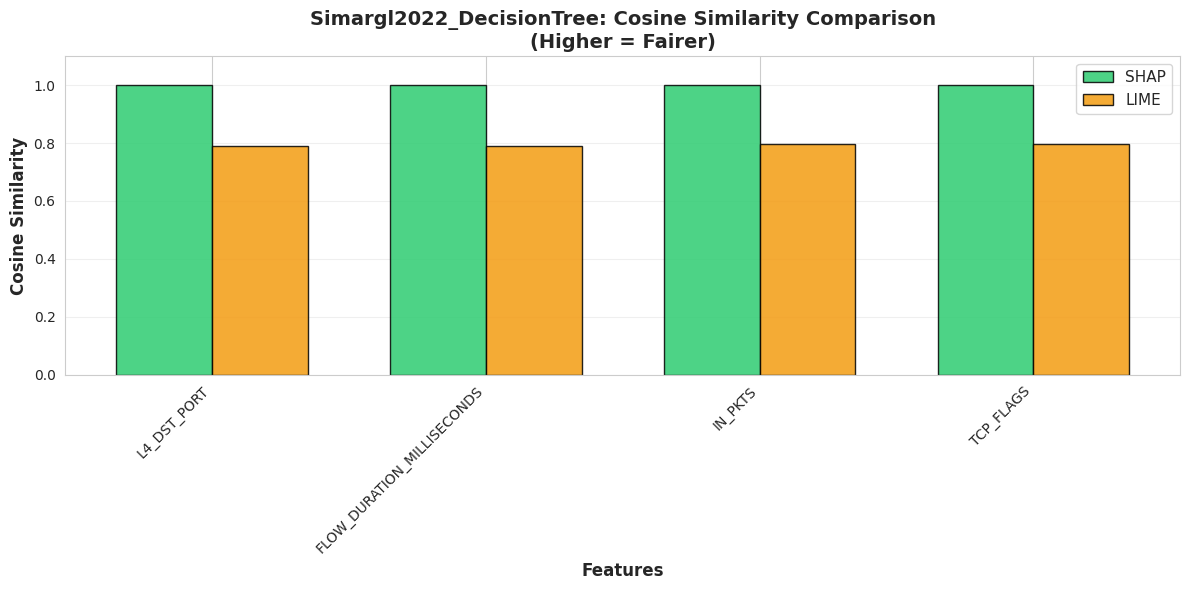

✓ Plot saved: Simargl2022_DecisionTree_Fairness_Scores.png


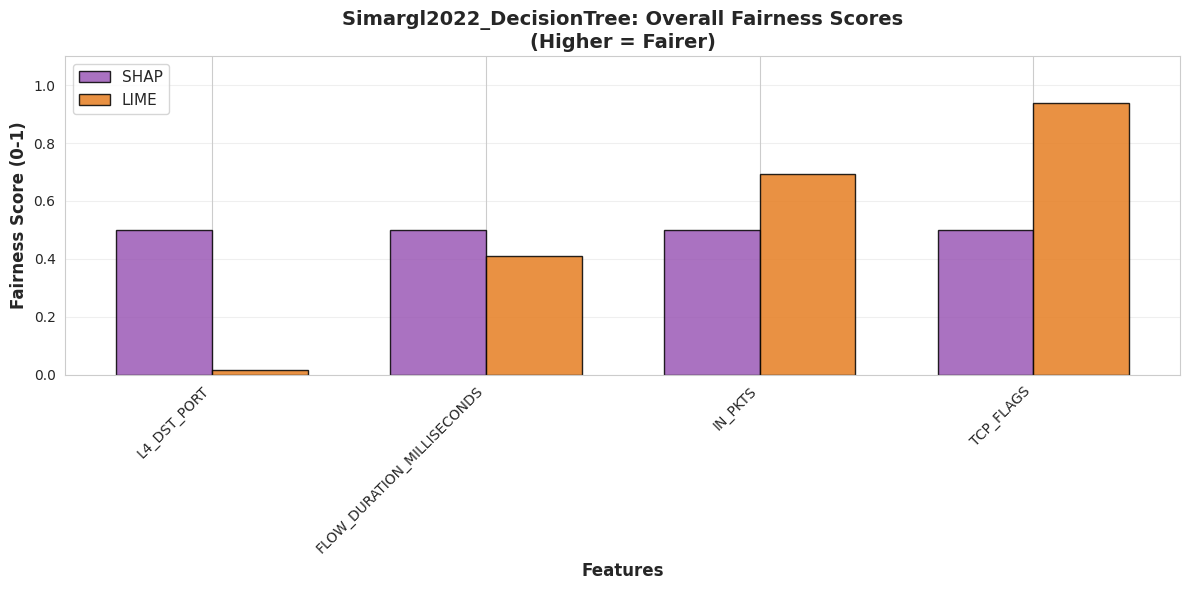


RESULTS SUMMARY


,Model,Feature,SHAP_MAD,LIME_MAD,SHAP_MAD_Std,LIME_MAD_Std,SHAP_Cosine,LIME_Cosine,SHAP_Cosine_Std,LIME_Cosine_Std,MAD_Winner,Cosine_Winner,Num_Instances,SHAP_Fairness_Score,LIME_Fairness_Score,Overall_Winner
0,Simargl2022_DecisionTree,L4_DST_PORT,0.000000,0.019249,0.000000,0.007623,1.000000,0.790765,0.000000,0.340445,SHAP,SHAP,514,0.5000,0.0167,SHAP
1,Simargl2022_DecisionTree,FLOW_DURATION_MILLISECONDS,0.000000,0.018956,0.000000,0.007663,1.000000,0.790522,0.000000,0.346366,SHAP,SHAP,514,0.5000,0.4099,SHAP
2,Simargl2022_DecisionTree,IN_PKTS,0.000000,0.019112,0.000000,0.007877,1.000000,0.797798,0.000000,0.324777,SHAP,SHAP,514,0.5000,0.6919,LIME
3,Simargl2022_DecisionTree,TCP_FLAGS,0.000000,0.018892,0.000000,0.007741,1.000000,0.796892,0.000000,0.328092,SHAP,SHAP,514,0.5000,0.9377,LIME



STATISTICAL VALIDATION


,Feature,MAD_Cohens_d,MAD_Effect_Size,MAD_Significant,Cosine_Cohens_d,Cosine_Effect_Size,Cosine_Significant
0,L4_DST_PORT,-3.567431,Large,Yes,0.868317,Large,Yes
1,FLOW_DURATION_MILLISECONDS,-3.494866,Large,Yes,0.854467,Large,Yes
2,IN_PKTS,-3.427911,Large,Yes,0.879613,Large,Yes
3,TCP_FLAGS,-3.448151,Large,Yes,0.874628,Large,Yes



 FAIRNESS EVALUATION COMPLETE

 Summary:
  Model: Simargl2022_DecisionTree
  Features evaluated: 4


In [ ]:
sys.path.insert(0, '../XAI_Meth_EVA_for_IDS_For_IeeeTDCS/XAI_Evaluation_Metrices')
import Fairness
from Fairness import XAIFairnessEvaluator

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, shapiro, levene
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

model_name = 'Simargl_DesionTree'
model = dt_model

candidate_sensitive = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'PSH Flag Count'
]

results_dict = {}
summary_data = []
statistical_tests = []
fairness_scores = []

for sensitive_feature in candidate_sensitive:
    print(f"Processing: {sensitive_feature}")
    
    fairness_evaluator = XAIFairnessEvaluator(
        model=model,
        feature_names=X_test.columns,
        sensitive_feature=sensitive_feature
    )
    
    shap_fairness = fairness_evaluator.evaluate_shap_fairness(
        explainer=Shap_explainer, instances=X_test, num_instances=1000
    )
    
    lime_fairness = fairness_evaluator.evaluate_lime_fairness(
        explainer=lime_explianer, instances=X_test, num_instances=1000
    )
    
    results_dict[sensitive_feature] = {'shap': shap_fairness, 'lime': lime_fairness}
    
    shap_mad_scores = shap_fairness['mad_scores']
    lime_mad_scores = lime_fairness['mad_scores']
    shap_cos_scores = shap_fairness['cosine_sims']
    lime_cos_scores = lime_fairness['cosine_sims']
    
    mad_stat, mad_pval = mannwhitneyu(shap_mad_scores, lime_mad_scores, alternative='two-sided')
    cos_stat, cos_pval = mannwhitneyu(shap_cos_scores, lime_cos_scores, alternative='two-sided')
    
    def cohens_d(group1, group2):
        n1, n2 = len(group1), len(group2)
        var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
        pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
        return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std != 0 else 0
    
    mad_cohens_d = cohens_d(shap_mad_scores, lime_mad_scores)
    cos_cohens_d = cohens_d(shap_cos_scores, lime_cos_scores)
    
    def confidence_interval(data, confidence=0.95):
        mean = np.mean(data)
        se = stats.sem(data)
        margin = se * stats.t.ppf((1 + confidence) / 2., len(data)-1)
        return mean - margin, mean + margin
    
    shap_mad_ci = confidence_interval(shap_mad_scores)
    lime_mad_ci = confidence_interval(lime_mad_scores)
    shap_cos_ci = confidence_interval(shap_cos_scores)
    lime_cos_ci = confidence_interval(lime_cos_scores)
    
    shap_mad_shapiro_p = shapiro(shap_mad_scores)[1]
    lime_mad_shapiro_p = shapiro(lime_mad_scores)[1]
    shap_cos_shapiro_p = shapiro(shap_cos_scores)[1]
    lime_cos_shapiro_p = shapiro(lime_cos_scores)[1]
    
    mad_levene_p = levene(shap_mad_scores, lime_mad_scores)[1]
    cos_levene_p = levene(shap_cos_scores, lime_cos_scores)[1]
    
    def interpret_cohens_d(d):
        abs_d = abs(d)
        if abs_d < 0.2: return "Negligible"
        elif abs_d < 0.5: return "Small"
        elif abs_d < 0.8: return "Medium"
        else: return "Large"
    
    statistical_tests.append({
        'Feature': sensitive_feature,
        'MAD_MannWhitney_U': mad_stat, 'MAD_MannWhitney_p': mad_pval,
        'MAD_Cohens_d': mad_cohens_d, 'MAD_Effect_Size': interpret_cohens_d(mad_cohens_d),
        'MAD_SHAP_CI_Lower': shap_mad_ci[0], 'MAD_SHAP_CI_Upper': shap_mad_ci[1],
        'MAD_LIME_CI_Lower': lime_mad_ci[0], 'MAD_LIME_CI_Upper': lime_mad_ci[1],
        'MAD_SHAP_Shapiro_p': shap_mad_shapiro_p, 'MAD_LIME_Shapiro_p': lime_mad_shapiro_p,
        'MAD_Levene_p': mad_levene_p,
        'Cosine_MannWhitney_U': cos_stat, 'Cosine_MannWhitney_p': cos_pval,
        'Cosine_Cohens_d': cos_cohens_d, 'Cosine_Effect_Size': interpret_cohens_d(cos_cohens_d),
        'Cosine_SHAP_CI_Lower': shap_cos_ci[0], 'Cosine_SHAP_CI_Upper': shap_cos_ci[1],
        'Cosine_LIME_CI_Lower': lime_cos_ci[0], 'Cosine_LIME_CI_Upper': lime_cos_ci[1],
        'Cosine_SHAP_Shapiro_p': shap_cos_shapiro_p, 'Cosine_LIME_Shapiro_p': lime_cos_shapiro_p,
        'Cosine_Levene_p': cos_levene_p,
        'MAD_Significant': 'Yes' if mad_pval < 0.05 else 'No',
        'Cosine_Significant': 'Yes' if cos_pval < 0.05 else 'No'
    })
    
    summary_data.append({
        'Feature': sensitive_feature,
        'SHAP_MAD': f"{shap_fairness['avg_mad']:.6f}",
        'LIME_MAD': f"{lime_fairness['avg_mad']:.6f}",
        'SHAP_MAD_Std': f"{shap_fairness['std_mad']:.6f}",
        'LIME_MAD_Std': f"{lime_fairness['std_mad']:.6f}",
        'SHAP_Cosine': f"{shap_fairness['avg_cosine']:.6f}",
        'LIME_Cosine': f"{lime_fairness['avg_cosine']:.6f}",
        'SHAP_Cosine_Std': f"{shap_fairness['std_cosine']:.6f}",
        'LIME_Cosine_Std': f"{lime_fairness['std_cosine']:.6f}",
        'MAD_Winner': 'SHAP' if shap_fairness['avg_mad'] < lime_fairness['avg_mad'] else 'LIME',
        'Cosine_Winner': 'SHAP' if shap_fairness['avg_cosine'] > lime_fairness['avg_cosine'] else 'LIME',
        'Num_Instances': shap_fairness['num_instances']
    })

# Fairness scores
from sklearn.preprocessing import MinMaxScaler

features = list(results_dict.keys())
shap_mad = [results_dict[f]['shap']['avg_mad'] for f in features]
lime_mad = [results_dict[f]['lime']['avg_mad'] for f in features]
shap_cosine = [results_dict[f]['shap']['avg_cosine'] for f in features]
lime_cosine = [results_dict[f]['lime']['avg_cosine'] for f in features]

scaler = MinMaxScaler()
shap_mad_norm = 1 - scaler.fit_transform(np.array(shap_mad).reshape(-1, 1)).flatten()
lime_mad_norm = 1 - scaler.fit_transform(np.array(lime_mad).reshape(-1, 1)).flatten()
shap_cosine_norm = scaler.fit_transform(np.array(shap_cosine).reshape(-1, 1)).flatten()
lime_cosine_norm = scaler.fit_transform(np.array(lime_cosine).reshape(-1, 1)).flatten()

shap_fairness_score = (shap_mad_norm + shap_cosine_norm) / 2
lime_fairness_score = (lime_mad_norm + lime_cosine_norm) / 2

for i, feature in enumerate(features):
    fairness_scores.append({
        'Feature': feature,
        'SHAP_Fairness_Score': f"{shap_fairness_score[i]:.4f}",
        'LIME_Fairness_Score': f"{lime_fairness_score[i]:.4f}",
        'Overall_Winner': 'SHAP' if shap_fairness_score[i] > lime_fairness_score[i] else 'LIME'
    })

summary_df = pd.DataFrame(summary_data)
stats_df = pd.DataFrame(statistical_tests)
fairness_df = pd.DataFrame(fairness_scores)

main_df = summary_df.copy()
for col in ['SHAP_Fairness_Score', 'LIME_Fairness_Score', 'Overall_Winner']:
    main_df[col] = fairness_df[col]
main_df.insert(0, 'Model', model_name)

# Save results
main_df.to_csv(f'{model_name}_Fairness_Results.csv', index=False)
stats_df.insert(0, 'Model', model_name)
stats_df.to_csv(f'{model_name}_Fairness_StatisticalTests.csv', index=False)
print(f"Saved: {model_name}_Fairness_Results.csv, {model_name}_Fairness_StatisticalTests.csv")

# Plots
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

fig, ax = plt.subplots(figsize=(12, 6))
features_list = main_df['Feature'].values
shap_mad = [float(val) for val in main_df['SHAP_MAD'].values]
lime_mad = [float(val) for val in main_df['LIME_MAD'].values]

x = np.arange(len(features_list))
width = 0.35

ax.bar(x - width/2, shap_mad, width, label='SHAP', color='#3498db', alpha=0.85, edgecolor='black')
ax.bar(x + width/2, lime_mad, width, label='LIME', color='#e74c3c', alpha=0.85, edgecolor='black')
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('MAD', fontsize=12)
ax.set_title(f'{model_name}: MAD Comparison')
ax.set_xticks(x)
ax.set_xticklabels(features_list, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
shap_cos = [float(val) for val in main_df['SHAP_Cosine'].values]
lime_cos = [float(val) for val in main_df['LIME_Cosine'].values]

ax.bar(x - width/2, shap_cos, width, label='SHAP', color='#2ecc71', alpha=0.85, edgecolor='black')
ax.bar(x + width/2, lime_cos, width, label='LIME', color='#f39c12', alpha=0.85, edgecolor='black')
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Cosine Similarity', fontsize=12)
ax.set_title(f'{model_name}: Cosine Similarity Comparison')
ax.set_xticks(x)
ax.set_xticklabels(features_list, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
shap_scores = [float(val) for val in main_df['SHAP_Fairness_Score'].values]
lime_scores = [float(val) for val in main_df['LIME_Fairness_Score'].values]

ax.bar(x - width/2, shap_scores, width, label='SHAP', color='#9b59b6', alpha=0.85, edgecolor='black')
ax.bar(x + width/2, lime_scores, width, label='LIME', color='#e67e22', alpha=0.85, edgecolor='black')
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Fairness Score', fontsize=12)
ax.set_title(f'{model_name}: Fairness Scores')
ax.set_xticks(x)
ax.set_xticklabels(features_list, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

display(main_df)
display(stats_df[['Feature', 'MAD_Cohens_d', 'MAD_Effect_Size', 'MAD_Significant', 
                   'Cosine_Cohens_d', 'Cosine_Effect_Size', 'Cosine_Significant']])

print(f"\nModel: {model_name}, Features: {len(candidate_sensitive)}")